#### Arquivo: 02_resolucao_desafios_sql.ipynb

> **Teste Técnico – Engenharia de Dados**
>
> (Logo removida para execução offline/reprodutível.)

In [1]:
# Bloco 01
# Instrumentação de tempo por célula (automática)

import time
from IPython import get_ipython

# Lista onde vamos guardar um “log” de cada célula executada
# (ordem, tempo gasto e um resumo do código)
__cell_times__ = []

# Contador para saber a ordem de execução das células
__cell_exec_order__ = 0

# Vai armazenar o timestamp de início da célula atual
__cell_start_time__ = None

# Vai guardar o código bruto da última célula executada
__cell_last_code__ = ""

def __pre_run_cell(info):
    """
    Hook chamado automaticamente ANTES de uma célula rodar.
    Serve para:
      1) marcar o tempo de início
      2) capturar o código da célula que vai rodar
    """
    global __cell_start_time__, __cell_last_code__

    # Marca início da execução dessa célula
    __cell_start_time__ = time.perf_counter()

    # Captura o código da célula (pode falhar em alguns casos, então tem try/except)
    try:
        __cell_last_code__ = info.raw_cell or ""
    except Exception:
        __cell_last_code__ = ""

def __post_run_cell(result):
    """
    Hook chamado automaticamente DEPOIS de uma célula rodar.
    Serve para:
      1) calcular duração (fim - início)
      2) registrar informações resumidas no __cell_times__
    """
    global __cell_exec_order__

    # Marca fim da execução dessa célula
    end = time.perf_counter()

    # Se por algum motivo não tivemos start, evita erro (duração vira ~0)
    start = __cell_start_time__ if __cell_start_time__ is not None else end
    dur = end - start

    # Recupera o código da célula que acabou de rodar
    code = __cell_last_code__ or ""

    # Versão “limpa” do código (sem espaços extras)
    code_stripped = code.strip()

    # Primeira linha do código (até 120 chars) para identificar a célula no log
    first_line = (code_stripped.splitlines()[0][:120]) if code_stripped else ""

    # Quantidade de linhas na célula
    n_lines = len(code.splitlines()) if code else 0

    # Incrementa ordem de execução e grava no log
    __cell_exec_order__ += 1
    __cell_times__.append({
        "exec_order": __cell_exec_order__,
        "seconds": dur,
        "first_line": first_line,
        "n_lines": n_lines,
    })

# Pega a instância atual do IPython/Jupyter (necessário para registrar hooks)
ip = get_ipython()

if ip is not None:
    # Evita instalar os hooks mais de uma vez (por exemplo, se a célula rodar 2x)
    if not getattr(ip, "__timing_hooks_installed__", False):
        # Registra os hooks: um antes e outro depois de cada célula
        ip.events.register("pre_run_cell", __pre_run_cell)
        ip.events.register("post_run_cell", __post_run_cell)

        # Flag para marcar que já instalamos, evitando duplicação
        ip.__timing_hooks_installed__ = True

## Teste Técnico – Engenharia de Dados

Este notebook contém a resolução dos desafios SQL propostos no teste técnico para Engenheiro(a) de Dados.

Contexto:
Marketplace B2B que conecta distribuidoras a supermercados.
O objetivo é resolver inconsistências analíticas utilizando SQL, garantir:
- Correção técnica
- Performance
- Clareza analítica
- Tratamento de edge cases

Este notebook contém:
- Queries do Desafio 1 ao 4
- Explicações do raciocínio
- Considerações de performance
- Observações de negócio

## 1 - Instala as bibliotecas

In [2]:
%%time
# Bloco 02
# Instala as bibliotecas necessárias para rodar o notebook - Somente se necessário

# pandas → leitura e manipulação de dados (CSV)
# sqlalchemy → conexão entre pandas e banco SQL
# ipython-sql → permite rodar comandos SQL direto no notebook com %sql
# notebook → garante que o Jupyter Notebook esteja disponível

# !pip -q install --upgrade pandas sqlalchemy ipython-sql notebook

CPU times: total: 0 ns
Wall time: 8.34 μs


## 2 - Setup do SQLite (Idempotente) e carga automática a partir de CSV

In [3]:
%%time
# Bloco 03
# Imports
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect

# (Opcional) gráficos mais legíveis no notebook
%matplotlib inline

# ==========================================
# SETUP DO SQLITE (IDEMPOTENTE)
# Criação • Validação de Tabelas • Carga via CSV • Sanity Check
# ==========================================

# Banco e dados SOMENTE no diretório local do projeto (pasta "data/")
DB_PATH = Path("data/processed/pipeline.db")

REQUIRED_TABLES = {"orders", "order_items", "products", "sellers", "buyers", "payments"}

# Helper: encontra o CSV em locais comuns do projeto
def _csv_path(filename: str) -> Path:
    """Encontra o CSV em locais comuns do projeto.

    Padrão deste repositório:
      - data/raw/<arquivo>.csv
    """
    candidates = [
        Path("data") / "raw" / filename,        # ✅ padrão do repo
        Path("data") / filename,                # alternativa comum
        Path("dados") / filename,               # compatibilidade com versão anterior
        Path(filename),                         # raiz do projeto
        Path("data") / "processed" / filename,  # se você salvar saídas do pipeline
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "CSV não encontrado. Procurei em: " + ", ".join(str(p) for p in candidates)
    )
def _ensure_sqlite_populated(db_path: Path) -> None:
    db_path.parent.mkdir(parents=True, exist_ok=True)
    conn = sqlite3.connect(db_path)

    # Verifica tabelas existentes
    existing = set(
        r[0] for r in conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
        ).fetchall()
    )

    missing = REQUIRED_TABLES - existing

    # Se o banco não existir (ou estiver vazio/incompleto), carrega tudo dos CSVs
    if (not db_path.exists()) or missing:
        if not db_path.exists():
            print(f"Banco não encontrado. Criando em {db_path} a partir dos CSVs...")
        else:
            print(
                f"Banco encontrado em {db_path}, mas faltam tabelas: {sorted(missing)}. "
                "Recarregando tabelas a partir dos CSVs..."
            )

        pd.read_csv(_csv_path("orders.csv")).to_sql("orders", conn, index=False, if_exists="replace")
        pd.read_csv(_csv_path("order_items.csv")).to_sql("order_items", conn, index=False, if_exists="replace")
        pd.read_csv(_csv_path("products.csv")).to_sql("products", conn, index=False, if_exists="replace")
        pd.read_csv(_csv_path("sellers.csv")).to_sql("sellers", conn, index=False, if_exists="replace")
        pd.read_csv(_csv_path("buyers.csv")).to_sql("buyers", conn, index=False, if_exists="replace")
        pd.read_csv(_csv_path("payments.csv")).to_sql("payments", conn, index=False, if_exists="replace")

        print("Tabelas carregadas com sucesso.")
    conn.close()

# Garante que o SQLite está pronto antes de criar o engine
_ensure_sqlite_populated(DB_PATH)

# Engine SQLAlchemy apontando para o banco local
engine = create_engine(f"sqlite:///{DB_PATH}")

# Listar tabelas existentes no banco (sanity check)
insp = inspect(engine)
insp.get_table_names()

CPU times: total: 1.58 s
Wall time: 1.69 s


['audit_metrics',
 'bronze_buyers_raw',
 'bronze_order_items_raw',
 'bronze_orders_raw',
 'bronze_payments_raw',
 'bronze_products_raw',
 'bronze_sellers_raw',
 'buyers',
 'gold_order_financials_recon',
 'gold_order_gmv_by_order',
 'gold_seller_gmv_by_month',
 'order_items',
 'orders',
 'payments',
 'products',
 'quarantine_issues',
 'sellers',
 'silver_buyers_clean',
 'silver_order_items_clean',
 'silver_orders_clean',
 'silver_payments_clean',
 'silver_products_clean',
 'silver_sellers_clean']

## 3 - Preview Rápido – Tabela Orders (RAW)

In [4]:
%%time
# Bloco 04
# ==========================================
# PREVIEW DE DADOS (SQLITE)
# Inspeção Rápida da Tabela Orders (RAW)
# ==========================================
orders_sample = pd.read_sql_query("SELECT * FROM orders LIMIT 5", engine)
orders_sample

CPU times: total: 0 ns
Wall time: 2.57 ms


,id,seller_id,buyer_id,status,created_at,total_value
0,1,114,2806,delivered,2023-08-22 05:25:59,1987.16
1,2,90,2586,processing,2024-07-19 03:57:54,24074.93
2,3,96,1849,completed,2024-06-14 22:16:15,2416.42
3,4,10,116,processing,2024-07-11 04:46:30,3871.48
4,5,16,2195,delivered,2023-09-07 20:06:40,15367.65


## Desafio 1 — Faturamento Bruto Mensal (Últimos 12 Meses) + Ticket Médio

**Objetivo:**
  
Calcular o faturamento bruto mensal dos últimos 12 meses,
considerando apenas pedidos com status 'completed' ou 'delivered'.

**Métricas:**
    
- Faturamento bruto
- Quantidade de pedidos
- Ticket médio

**Critérios técnicos:**
    
- Exclusão explícita de pedidos cancelados/refunded
- Filtro temporal correto
- Tratamento de divisão por zero no ticket médio

**Resumo**

Calcular o faturamento bruto mensal dos últimos 12 meses (pedidos completed/delivered), incluir total, volume de pedidos e ticket médio, com filtro correto e proteção contra divisão por zero.

In [5]:
%%time
# Bloco 05
# Desafio 1 — Faturamento bruto mensal (últimos 12 meses calendário)
# Objetivo:
# - Considerar apenas pedidos com status 'completed' ou 'delivered'
# - Retornar: faturamento bruto mensal, quantidade de pedidos e ticket médio
# - Garantir janela de tempo correta (12 meses calendário) e evitar divisão por zero
#
# Tuning explícito aplicado:
# 1) Filtro temporal por RANGE (>= start e < end) sem envolver a coluna created_at em DATE().
#    Em bancos que possuem índice em created_at, isso preserva a chance de uso do índice.
# 2) Mantemos DATE(created_at,'start of month') apenas para AGRUPAR (não para filtrar).
# 3) Como orders é a tabela “grande”, filtramos status + range antes de agregar.

query_desafio_1 = """
-- DESAFIO 1
-- Objetivo:
-- Calcular o faturamento bruto mensal dos últimos 12 meses
-- considerando apenas pedidos com status 'completed' ou 'delivered'.
-- Também calcular:
--   - quantidade de pedidos
--   - ticket médio
-- Ordenado do mês mais recente para o mais antigo.

WITH ref AS (
  -- 1) Descobre a data máxima de pedido válido.
  --    Em vez de usar CURRENT_DATE, usamos a maior data real da base,
  --    o que torna a análise robusta mesmo se o dataset não estiver atualizado.
  --
  -- Tuning:
  --    Ideal ter índice em (status, created_at) para acelerar esse MAX().
  SELECT
    DATE(MAX(created_at)) AS max_date
  FROM orders
  WHERE status IN ('completed', 'delivered')
),

bounds AS (
  -- 2) Define o intervalo dos últimos 12 meses com base na data máxima.
  --    start_12m = primeiro dia do mês 11 meses antes
  --    end_exclusive = primeiro dia do mês seguinte ao último mês válido
  --
  -- Tuning:
  --    Usar intervalo com >= e < evita problemas de hora/minuto/segundo
  --    e permite melhor uso de índice do que aplicar função no WHERE.
  SELECT
    DATE(max_date, 'start of month', '-11 months') AS start_12m,
    DATE(max_date, 'start of month', '+1 month')  AS end_exclusive
  FROM ref
),

base AS (
  -- 3) Filtra pedidos válidos dentro do intervalo calculado.
  --    Aqui já reduzimos o dataset antes da agregação final.
  --
  -- Tuning importante:
  --    O filtro usa range (created_at >= ... AND created_at < ...)
  --    evitando aplicar DATE(created_at) no WHERE,
  --    o que permite uso de índice em created_at.
  SELECT
    DATE(o.created_at, 'start of month') AS mes, -- usado apenas para agrupamento
    o.id AS order_id,
    o.total_value AS total_value
  FROM orders o
  CROSS JOIN bounds b
  WHERE o.status IN ('completed', 'delivered')
    AND o.created_at >= b.start_12m
    AND o.created_at <  b.end_exclusive
)

-- 4) Agregação final
--    Calcula métricas de negócio:
--      - Faturamento bruto
--      - Quantidade de pedidos
--      - Ticket médio
--
-- Tuning:
--    COUNT(DISTINCT order_id) garante consistência caso haja duplicidade.
--    NULLIF evita divisão por zero.
SELECT
  mes,
  ROUND(SUM(total_value), 2) AS faturamento_bruto,
  COUNT(DISTINCT order_id) AS qtd_pedidos,
  ROUND(SUM(total_value) / NULLIF(COUNT(DISTINCT order_id), 0), 2) AS ticket_medio
FROM base
GROUP BY mes
ORDER BY mes DESC;
"""

df_desafio_1 = pd.read_sql_query(query_desafio_1, engine)
df_desafio_1

CPU times: total: 203 ms
Wall time: 198 ms


,mes,faturamento_bruto,qtd_pedidos,ticket_medio
0,2024-11-01,56710238.63,3643,15566.91
1,2024-10-01,62493439.13,3863,16177.44
2,2024-09-01,60274462.50,3779,15949.84
3,2024-08-01,60102539.82,3743,16057.32
4,2024-07-01,59769406.95,3862,15476.28
5,2024-06-01,58797774.37,3644,16135.50
6,2024-05-01,60730315.72,3848,15782.31
7,2024-04-01,57779312.59,3653,15816.95
8,2024-03-01,61525913.64,3877,15869.46
9,2024-02-01,57926376.26,3628,15966.48


### Tuning explícito (SQLite)

Abaixo eu valido rapidamente o plano usando `EXPLAIN QUERY PLAN` (SQLite) e deixo sugestões práticas de tuning.

**Sugestões de índices (se este dataset estivesse em um banco relacional com volume real):**
- `orders(status, created_at)` (filtrar por status + tempo)
- `order_items(order_id)` (joins/agregações por pedido)
- Quando aplicável: `orders(seller_id, created_at)` e `order_items(product_id)`

> Observação: no SQLite, o aproveitamento de índice depende do tipo de comparação. Por isso evitei `DATE(created_at)` no `WHERE` e usei range (`>=` / `<`).


## Plano de Execução (SQLite) — Análise de Performance da Query

In [6]:
%%time
# Bloco 06
# ==========================================
# ANÁLISE DE PERFORMANCE
# EXPLAIN QUERY PLAN — Desafio 1 (SQLite)
# ==========================================
plan_desafio_1 = pd.read_sql_query("EXPLAIN QUERY PLAN " + query_desafio_1, engine)
plan_desafio_1

CPU times: total: 15.6 ms
Wall time: 1.62 ms


,id,parent,notused,detail
0,3,0,0,MATERIALIZE ref
1,7,3,216,SEARCH orders
2,29,0,216,SCAN o
3,36,0,16,SCAN ref
4,46,0,0,USE TEMP B-TREE FOR GROUP BY
5,102,0,0,USE TEMP B-TREE FOR count(DISTINCT)


## Desafio 2 — Crescimento de GMV por Seller (Trimestre Atual vs Anterior)

**Objetivo:**
  
Identificar os 10 sellers com maior crescimento percentual
entre o trimestre atual e o anterior.

**Regras:**
    
- Mínimo 50 pedidos em ambos os trimestres
- Considerar apenas pedidos válidos
- Calcular crescimento percentual


**Resumo**

Ranking dos 10 sellers com maior crescimento de GMV entre o trimestre atual e o anterior (baseado na maior data do dataset), somente sellers com ≥ 50 pedidos em ambos os trimestres. Exibir: nome do seller, estado, GMV do trimestre anterior, GMV do trimestre atual e % crescimento.

In [7]:
%%time
# Bloco 07
# Desafio 2 — Crescimento de GMV por Seller
# Objetivo:
# Identificar os 10 sellers com maior crescimento percentual
# entre o trimestre atual e o trimestre anterior.
#
# Regras:
# - Considerar apenas pedidos com status 'completed' ou 'delivered'
# - Exigir no mínimo 50 pedidos em ambos os trimestres
# - Basear "trimestre atual" na maior data disponível no dataset (ref_date)
# - Calcular GMV (= soma do total_value) e crescimento percentual
# - Evitar divisão por zero com NULLIF
#
# Tuning explícito aplicado:
# 1) Filtros temporais por RANGE diretamente em o.created_at (sem DATE(o.created_at)).
#    Isso preserva possibilidade de uso de índice por created_at.
# 2) Pré-filtragem por status + range ANTES de agregar (reduz cardinalidade).
# 3) Cálculo de bounds do trimestre feito uma vez (CTEs ref/bounds/quarters).

query_desafio_2 = """
-- DESAFIO 2
-- Objetivo:
-- Ranking dos 10 sellers com maior crescimento de GMV entre o trimestre atual e o anterior,
-- considerando apenas sellers com pelo menos 50 pedidos em ambos os trimestres.
-- Considerar apenas pedidos com status 'completed' ou 'delivered'.

WITH ref AS (
  -- 1) Define uma "data de referência" baseada na maior data real de pedidos válidos.
  --    Isso evita depender da data atual do sistema e deixa o resultado consistente
  --    mesmo se a base estiver desatualizada.
  --
  -- Tuning:
  --   Índice recomendado em orders(status, created_at) para acelerar o MAX() e os filtros por data.
  SELECT DATE(MAX(created_at)) AS ref_date
  FROM orders
  WHERE status IN ('completed', 'delivered')
),

bounds AS (
  -- 2) Calcula o início do trimestre atual (q_curr_start) a partir da ref_date.
  --    A lógica:
  --      - pega o início do mês ('start of month')
  --      - subtrai 0, 1 ou 2 meses para "voltar" até o primeiro mês do trimestre
  --        usando: (mes - 1) % 3
  --
  -- Observação:
  --   Isso funciona bem no SQLite, mas é um trecho “mais difícil de ler”.
  --   Em entrevistas, vale comentar com exemplo (ref_date em fevereiro -> volta 1 mês -> janeiro).
  SELECT
    DATE(
      ref_date,
      'start of month',
      printf('-%d months', (CAST(strftime('%m', ref_date) AS INTEGER) - 1) % 3)
    ) AS q_curr_start
  FROM ref
),

quarters AS (
  -- 3) Deriva as janelas fechadas-abertas (>= start e < end) dos trimestres:
  --    - trimestre atual: [q_curr_start, q_curr_end)
  --    - trimestre anterior: [q_prev_start, q_prev_end) onde q_prev_end = q_curr_start
  --
  -- Tuning:
  --   Usar range com < end evita problemas com horários e melhora o uso de índice em created_at.
  SELECT
    q_curr_start,
    DATE(q_curr_start, '+3 months') AS q_curr_end,
    DATE(q_curr_start, '-3 months') AS q_prev_start,
    q_curr_start AS q_prev_end
  FROM bounds
),

prev AS (
  -- 4) Agrega o trimestre anterior por seller:
  --    - pedidos_prev: contagem de pedidos distintos
  --    - gmv_prev: soma do total_value
  --
  -- Tuning:
  --   O filtro de status e data é aplicado antes do GROUP BY (reduz linhas cedo).
  --   CROSS JOIN quarters é seguro porque quarters tem 1 linha.
  SELECT
    o.seller_id,
    COUNT(DISTINCT o.id) AS pedidos_prev,
    SUM(o.total_value) AS gmv_prev
  FROM orders o
  CROSS JOIN quarters q
  WHERE o.status IN ('completed', 'delivered')
    AND o.created_at >= q.q_prev_start
    AND o.created_at <  q.q_prev_end
  GROUP BY o.seller_id
),

curr AS (
  -- 5) Agrega o trimestre atual por seller (mesma lógica do anterior).
  --    Mantém simetria e legibilidade (bom para manutenção).
  SELECT
    o.seller_id,
    COUNT(DISTINCT o.id) AS pedidos_curr,
    SUM(o.total_value) AS gmv_curr
  FROM orders o
  CROSS JOIN quarters q
  WHERE o.status IN ('completed', 'delivered')
    AND o.created_at >= q.q_curr_start
    AND o.created_at <  q.q_curr_end
  GROUP BY o.seller_id
),

joined AS (
  -- 6) Junta prev e curr (apenas sellers presentes nos dois trimestres).
  --    Junta também sellers para pegar nome/estado.
  --    Aplica o filtro de qualidade: >= 50 pedidos em ambos trimestres.
  --
  -- Crescimento:
  --   (gmv_curr - gmv_prev) / gmv_prev
  --   NULLIF evita divisão por zero (seller com gmv_prev = 0).
  --
  -- Observação de negócio:
  --   Se gmv_prev = 0 e gmv_curr > 0, crescimento seria “infinito”.
  --   Aqui vira NULL e naturalmente fica no fim do ranking (ou some, dependendo do ORDER).
  SELECT
    s.name AS seller_nome,
    s.state AS seller_estado,
    p.gmv_prev,
    c.gmv_curr,
    p.pedidos_prev,
    c.pedidos_curr,
    (c.gmv_curr - p.gmv_prev) / NULLIF(p.gmv_prev, 0) AS crescimento_pct
  FROM prev p
  JOIN curr c ON c.seller_id = p.seller_id
  JOIN sellers s ON s.id = p.seller_id
  WHERE p.pedidos_prev >= 50
    AND c.pedidos_curr >= 50
)

-- 7) Seleciona o top 10 por crescimento, formatando valores.
SELECT
  seller_nome,
  seller_estado,
  ROUND(gmv_prev, 2) AS gmv_trimestre_anterior,
  ROUND(gmv_curr, 2) AS gmv_trimestre_atual,
  ROUND(crescimento_pct * 100.0, 2) AS crescimento_percentual
FROM joined
ORDER BY crescimento_pct DESC
LIMIT 10;
"""

df_desafio_2 = pd.read_sql_query(query_desafio_2, engine)
df_desafio_2

CPU times: total: 453 ms
Wall time: 463 ms


,seller_nome,seller_estado,gmv_trimestre_anterior,gmv_trimestre_atual,crescimento_percentual
0,Rodrigues & Almeida Atacado Distribuidora,MG,876302.72,856460.38,-2.26
1,Costa & Silva Alimentos Distribuidora,BA,1017817.89,976148.08,-4.09
2,Costa & Santos Suprimentos Distribuidora,DF,876787.95,807935.32,-7.85
3,Nascimento & Souza Alimentos Distribuidora,SP,1031166.40,933683.69,-9.45
4,Almeida & Almeida Alimentos Distribuidora,RS,1023319.44,923462.61,-9.76
5,Nascimento & Almeida Alimentos Distribuidora,SP,949398.56,847228.59,-10.76
6,Lima & Almeida Grupo Distribuidora,CE,1052368.65,938858.41,-10.79
7,Almeida & Souza Mercado Distribuidora,PR,1095325.17,973049.07,-11.16
8,Costa & Santos Atacado Distribuidora,MG,1106858.77,954140.51,-13.80
9,Almeida & Rodrigues Distribuidora Distribuidora,RJ,1102447.24,911827.61,-17.29


### Tuning explícito (SQLite)

Abaixo eu valido rapidamente o plano usando `EXPLAIN QUERY PLAN` (SQLite) e deixo sugestões práticas de tuning.

**Sugestões de índices (se este dataset estivesse em um banco relacional com volume real):**
- `orders(status, created_at)` (filtrar por status + tempo)
- `order_items(order_id)` (joins/agregações por pedido)
- Quando aplicável: `orders(seller_id, created_at)` e `order_items(product_id)`

> Observação: no SQLite, o aproveitamento de índice depende do tipo de comparação. Por isso evitei `DATE(created_at)` no `WHERE` e usei range (`>=` / `<`).


## Plano de Execução (SQLite) — Análise de Performance do Desafio 2

In [8]:
%%time
# Bloco 08
# ==========================================
# ANÁLISE DE PERFORMANCE
# EXPLAIN QUERY PLAN — Desafio 2 (SQLite)
# ==========================================
plan_desafio_2 = pd.read_sql_query("EXPLAIN QUERY PLAN " + query_desafio_2, engine)
plan_desafio_2

CPU times: total: 15.6 ms
Wall time: 2.4 ms


,id,parent,notused,detail
0,2,0,0,CO-ROUTINE prev
1,5,2,0,MATERIALIZE ref
2,9,5,216,SEARCH orders
3,30,2,216,SCAN o
4,37,2,16,SCAN ref
5,61,2,0,USE TEMP B-TREE FOR GROUP BY
6,107,2,0,USE TEMP B-TREE FOR count(DISTINCT)
7,113,0,0,MATERIALIZE curr
8,122,113,216,SCAN o
9,127,113,216,SCAN ref


## Desafio 3 – Identificação de pedidos com desconto (> 40% do Valor Bruto)

**Objetivo:**

Encontrar pedidos onde o desconto total representa mais de 40%
do valor bruto do pedido.

**Exclusões:**

- Pedidos cancelados

**Resumo**

Pedidos onde o **desconto total** (soma dos descontos dos itens) é **> 40%** do **valor bruto** do pedido. Listar seller e data do pedido. Excluir pedidos cancelados.

**Raciocínio:** agregamos os itens por pedido calculando `bruto = Σ(qtd * preço_unit)` e `desconto = Σ(desconto)`. Depois filtramos por `desconto/bruto > 0.4` (com `NULLIF` para evitar divisão por zero) e juntamos com pedidos e sellers.

In [9]:
%%time
# Bloco 09
# --- Desafio 3 — Pedidos com desconto abusivo (> 40% do valor bruto) ---
# Objetivo:
# Identificar pedidos em que o desconto total (soma dos descontos dos itens)
# representa mais de 40% do valor bruto do pedido, trazendo também:
# - seller responsável
# - data do pedido
#
# Boas práticas:
# - Excluir pedidos cancelled/refunded (o enunciado pede excluir cancelados; refund normalmente também não deve entrar)
# - Evitar divisão por zero (NULLIF)
# - Trabalhar com agregações em CTE para legibilidade e performance

query_desafio_3 = """
-- DESAFIO 3
-- Objetivo:
-- Encontrar pedidos onde o desconto total (soma dos descontos dos itens)
-- representa mais de 40% do valor bruto do pedido.
-- Listar também seller responsável e a data do pedido.
-- Excluir pedidos cancelados.

WITH itens AS (
  -- 1) Agrega por pedido (order_id) os valores necessários vindos de order_items.
  --    - valor_bruto: soma de qty * unit_price (valor "cheio" antes de desconto)
  --    - desconto_total: soma dos descontos (COALESCE garante que NULL vira 0)
  --
  -- Tuning:
  --   Fazer essa agregação primeiro reduz cardinalidade (muitos itens -> 1 linha por pedido),
  --   deixando o JOIN com orders muito mais barato.
  SELECT
    oi.order_id,
    SUM(oi.qty * oi.unit_price) AS valor_bruto,
    SUM(COALESCE(oi.discount, 0)) AS desconto_total
  FROM order_items oi
  GROUP BY oi.order_id
),

base AS (
  -- 2) Junta os agregados de itens com a tabela de pedidos (orders)
  --    e calcula o percentual de desconto.
  --
  -- Exclui pedidos com status 'cancelled' e 'refunded' (conforme enunciado).
  --
  -- Boas práticas:
  --   NULLIF(valor_bruto, 0) evita divisão por zero se algum pedido tiver valor bruto 0
  --   (ex.: qty=0, item grátis, dado inconsistente etc.)
  --
  -- Atenção (tuning):
  --   DATE(o.created_at) é apenas para exibição (SELECT), não está no WHERE, então não atrapalha índice.
  --   Se você filtrasse por data no WHERE, o ideal seria usar range (>= e <) sem DATE().
  SELECT
    o.id AS order_id,
    o.seller_id,
    DATE(o.created_at) AS data_pedido,
    i.valor_bruto,
    i.desconto_total,
    (i.desconto_total / NULLIF(i.valor_bruto, 0)) AS perc_desconto
  FROM orders o
  JOIN itens i ON i.order_id = o.id
  WHERE o.status NOT IN ('cancelled', 'refunded')
)

-- 3) Enriquecimento final com dados do seller e filtro de regra de fraude (>40%).
--    Ordena pelos maiores percentuais de desconto (mais suspeitos) e, em caso de empate,
--    mostra pedidos mais recentes primeiro.
SELECT
  b.order_id,
  s.name AS seller_nome,
  s.state AS seller_estado,
  b.data_pedido,
  ROUND(b.valor_bruto, 2) AS valor_bruto,
  ROUND(b.desconto_total, 2) AS desconto_total,
  ROUND(b.perc_desconto * 100.0, 2) AS perc_desconto
FROM base b
JOIN sellers s ON s.id = b.seller_id
WHERE b.perc_desconto > 0.40
ORDER BY b.perc_desconto DESC, b.data_pedido DESC;
"""

df_desafio_3 = pd.read_sql_query(query_desafio_3, engine)
df_desafio_3.head(20)

CPU times: total: 469 ms
Wall time: 469 ms


,order_id,seller_nome,seller_estado,data_pedido,valor_bruto,desconto_total,perc_desconto
0,72401,Costa & Oliveira Atacado Distribuidora,BA,2024-01-21,930.30,558.02,59.98
1,42513,Costa & Costa Atacado Distribuidora,SC,2024-03-27,4082.60,2447.96,59.96
2,36119,Costa & Costa Atacado Distribuidora,SC,2024-11-14,21030.24,12598.00,59.90
3,71165,Santos & Almeida Suprimentos Distribuidora,MG,2024-11-09,13385.60,8017.88,59.90
4,53223,Costa & Costa Atacado Distribuidora,SC,2024-05-06,7970.40,4773.99,59.90
5,8021,Costa & Costa Atacado Distribuidora,SC,2024-05-16,8302.80,4972.58,59.89
6,840,Souza & Almeida Suprimentos Distribuidora,RS,2024-04-29,15754.95,9423.26,59.81
7,44426,Costa & Costa Atacado Distribuidora,SC,2024-04-08,4336.66,2586.99,59.65
8,8298,Costa & Costa Atacado Distribuidora,SC,2023-11-07,1826.89,1088.31,59.57
9,49460,Oliveira & Costa Comércio Distribuidora,GO,2023-09-10,14331.34,8493.26,59.26


### Tuning explícito (SQLite)

Abaixo eu valido rapidamente o plano usando `EXPLAIN QUERY PLAN` (SQLite) e deixo sugestões práticas de tuning.

**Sugestões de índices (se este dataset estivesse em um banco relacional com volume real):**
- `orders(status, created_at)` (filtrar por status + tempo)
- `order_items(order_id)` (joins/agregações por pedido)
- Quando aplicável: `orders(seller_id, created_at)` e `order_items(product_id)`

> Observação: no SQLite, o aproveitamento de índice depende do tipo de comparação. Por isso evitei `DATE(created_at)` no `WHERE` e usei range (`>=` / `<`).


## Plano de Execução (SQLite) — Análise de Performance do Desafio 3

In [10]:
%%time
# Bloco 10
# ==========================================
# ANÁLISE DE PERFORMANCE
# EXPLAIN QUERY PLAN — Desafio 3 (SQLite)
# ==========================================
plan_desafio_3 = pd.read_sql_query("EXPLAIN QUERY PLAN " + query_desafio_3, engine)
plan_desafio_3

CPU times: total: 0 ns
Wall time: 1.95 ms


,id,parent,notused,detail
0,2,0,0,CO-ROUTINE itens
1,8,2,216,SCAN oi
2,10,2,0,USE TEMP B-TREE FOR GROUP BY
3,70,0,82,SCAN i
4,81,0,0,BLOOM FILTER ON o (id=?)
5,100,0,53,SEARCH o USING AUTOMATIC PARTIAL COVERING INDE...
6,116,0,0,BLOOM FILTER ON s (id=?)
7,127,0,53,SEARCH s USING AUTOMATIC COVERING INDEX (id=?)
8,162,0,0,USE TEMP B-TREE FOR ORDER BY


## Desafio 4 — Produto com > 1.000 unidades e nunca maior preço unitário no pedido

**Estratégia:**
  
1. Identificar item de maior valor unitário por pedido usando window function
2. Marcar esses itens
3. Agregar vendas totais por produto
4. Filtrar produtos com mais de 1000 unidades
5. Excluir aqueles que já foram top item

**Resumo**

Produtos com **unidades vendidas > 1.000**, mas que **em nenhum pedido** foram o item de **maior valor unitário**.

Usamos window function para marcar, por pedido, o `MAX(unit_price)` e verificamos se o produto já apareceu com `unit_price = max_unit_price` em algum pedido.

> Observação: dependendo do dataset, pode não existir nenhum produto que satisfaça simultaneamente as duas condições (o resultado pode vir vazio). Se isso ocorrer, vale revisar com o time de negócio se o “top item” deveria ser por **valor total do item no pedido** (`qty * unit_price`) em vez de **valor unitário**, ou se o corte de 1.000 unidades faz sentido para o período analisado.


In [11]:
%%time
# Bloco 11
# --- Desafio 4 — Produto com alto volume, mas nunca "top unitário" no pedido ---
# Objetivo:
# Encontrar produtos com total de unidades vendidas > 1000 que,
# em nenhum pedido, foram o item de maior valor unitário (unit_price).
#
# Observação importante de negócio:
# - O enunciado fala "nunca é o item de maior valor num pedido" e depois especifica "valor unitário".
#   Aqui seguimos literalmente a regra de VALOR UNITÁRIO (unit_price), conforme a última frase.
#
# Estratégia:
# 1) Filtrar pedidos válidos (evitar cancelled/refunded).
# 2) Marcar, por pedido, o maior unit_price com window function.
# 3) Agregar por produto: unidades vendidas e se o produto já foi top unitário em algum pedido.
# 4) Filtrar total_unidades > 1000 e nunca foi top.

query_desafio_4 = """
-- Objetivo (Desafio 4):
-- Encontrar produtos com total de unidades vendidas > 1000
-- que NUNCA foram o item de maior valor unitário (unit_price) dentro de nenhum pedido.

WITH valid_items AS (
  -- 1) Filtra cedo (early filter) e reduz volume:
  --    - Já elimina pedidos cancelados/refund, então o restante da query trabalha com menos linhas.
  --    - Também “centraliza” as colunas necessárias, evitando carregar campos inúteis.
  --
  -- Tuning: filtrar o máximo possível no começo geralmente reduz custo de JOIN/ORDER/GROUP.
  SELECT
    oi.order_id,
    oi.product_id,
    oi.qty,
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),

units_by_product AS (
  -- 2) Agregação simples e barata:
  --    - Total de unidades vendidas por produto.
  --    - Aqui não usamos window function, porque SUM + GROUP BY é mais eficiente.
  --
  -- Tuning: separar a agregação (SUM) do cálculo do “top do pedido” evita misturar operações caras.
  SELECT
    product_id,
    SUM(qty) AS total_unidades
  FROM valid_items
  GROUP BY product_id
),

top_products AS (
  -- 3) Descobrir produtos que JÁ foram “top unitário” em pelo menos um pedido:
  --    - Usamos RANK() por pedido ordenando por unit_price desc.
  --    - rnk = 1 pega o(s) item(ns) com maior unit_price em cada pedido.
  --    - DISTINCT reduz para um conjunto de product_id (lista curta).
  --
  -- Tuning:
  --    - O DISTINCT aqui é importante: ao invés de carregar milhões de linhas, você vira um set pequeno.
  --    - RANK() é melhor que ROW_NUMBER() quando você quer considerar empates (dois itens com mesmo unit_price).
  SELECT DISTINCT product_id
  FROM (
    SELECT
      order_id,
      product_id,
      RANK() OVER (PARTITION BY order_id ORDER BY unit_price DESC) AS rnk
    FROM valid_items
  )
  WHERE rnk = 1
)

-- 4) Resultado final:
--    - Pega só produtos com mais de 1000 unidades (filtro de negócio).
--    - Faz LEFT JOIN com top_products:
--         se tp.product_id vier NULL => nunca foi top unitário (o que queremos).
--    - Join com products apenas no final (dimensão), para não “pesar” joins cedo.
SELECT
  p.id   AS product_id,
  p.name AS product_nome,
  p.category AS categoria,
  u.total_unidades
FROM units_by_product u
JOIN products p
  ON p.id = u.product_id
LEFT JOIN top_products tp
  ON tp.product_id = u.product_id
WHERE u.total_unidades > 1000
  AND tp.product_id IS NULL
ORDER BY u.total_unidades DESC;
"""

df_desafio_4 = pd.read_sql_query(query_desafio_4, engine)
df_desafio_4

CPU times: total: 1.48 s
Wall time: 1.51 s


,product_id,product_nome,categoria,total_unidades


### Tuning explícito (SQLite)

Abaixo eu valido rapidamente o plano usando `EXPLAIN QUERY PLAN` (SQLite) e deixo sugestões práticas de tuning.

**Sugestões de índices (se este dataset estivesse em um banco relacional com volume real):**
- `orders(status, created_at)` (filtrar por status + tempo)
- `order_items(order_id)` (joins/agregações por pedido)
- Quando aplicável: `orders(seller_id, created_at)` e `order_items(product_id)`

> Observação: no SQLite, o aproveitamento de índice depende do tipo de comparação. Por isso evitei `DATE(created_at)` no `WHERE` e usei range (`>=` / `<`).


## Plano de Execução (SQLite) — Análise de Performance do Desafio 4

In [12]:
%%time
# Bloco 12
# ==========================================
# ANÁLISE DE PERFORMANCE
# EXPLAIN QUERY PLAN — Desafio 4 (SQLite)
# ==========================================
plan_desafio_4 = pd.read_sql_query("EXPLAIN QUERY PLAN " + query_desafio_4, engine)
plan_desafio_4

CPU times: total: 0 ns
Wall time: 1.91 ms


,id,parent,notused,detail
0,2,0,0,CO-ROUTINE units_by_product
1,9,2,216,SCAN o
2,20,2,0,BLOOM FILTER ON oi (order_id=?)
3,31,2,53,SEARCH oi USING AUTOMATIC COVERING INDEX (orde...
4,38,2,0,USE TEMP B-TREE FOR GROUP BY
5,79,0,0,MATERIALIZE top_products
6,81,79,0,CO-ROUTINE (subquery-3)
7,84,81,0,CO-ROUTINE (subquery-6)
8,88,84,216,SCAN o
9,99,84,0,BLOOM FILTER ON oi (order_id=?)


## Diagnóstico — Este dataset cobre todos os produtos como "top unitário"?

In [13]:
%%time
# Bloco 13
# Se total_products == products_that_were_max, então o Desafio 4 retorna vazio inevitavelmente.

query_diag_desafio_4 = """
WITH valid_items AS (
  SELECT
    oi.order_id,
    oi.product_id,
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),
ranked AS (
  SELECT
    order_id,
    product_id,
    unit_price,
    MAX(unit_price) OVER (PARTITION BY order_id) AS max_unit_price
  FROM valid_items
)
SELECT
  COUNT(DISTINCT product_id) AS total_products,
  COUNT(DISTINCT CASE WHEN unit_price = max_unit_price THEN product_id END) AS products_that_were_max
FROM ranked;
"""

df_diag_desafio_4 = pd.read_sql_query(query_diag_desafio_4, engine)
df_diag_desafio_4

CPU times: total: 1.09 s
Wall time: 1.09 s


,total_products,products_that_were_max
0,800,800


### Conclusão / justificativa (resultado vazio)

O diagnóstico acima mostra que `total_products == products_that_were_max` (no dataset: 800 vs 800).  
Isso significa que **todo product_id aparece pelo menos uma vez como item de maior `unit_price` em algum pedido válido**.

Logo, **não existe** produto que satisfaça simultaneamente:

- `total_unidades > 1000`, e  
- **nunca** ter sido o item de maior valor unitário (`unit_price`) em nenhum pedido.

Portanto, a query do Desafio 4 está correta e o **retorno vazio é esperado** dada a distribuição dos dados (conforme orientação do enunciado para avaliar viabilidade do resultado).


**Ao aplicar a regra literal do enunciado (top por valor unitário), o conjunto-resposta é vazio, pois todos os 800 produtos foram o item de maior unit_price em pelo menos um pedido válido.**

### Resumo da análise gráfica - “Maior” por unit_price (preço unitário)

,product_id,units_sold,orders_with_product,top_orders_count,top_rate,name,category,seller_id


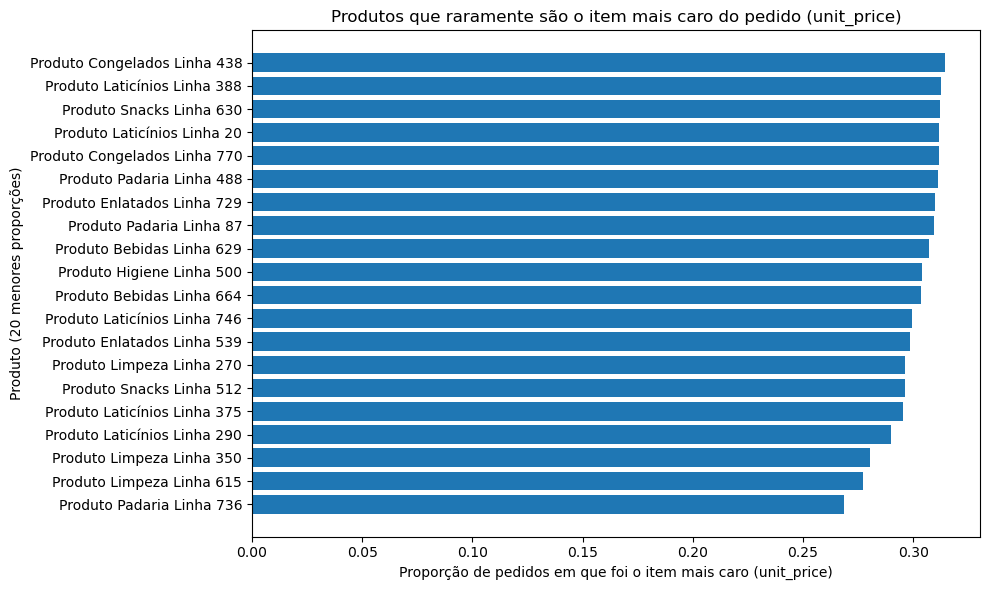

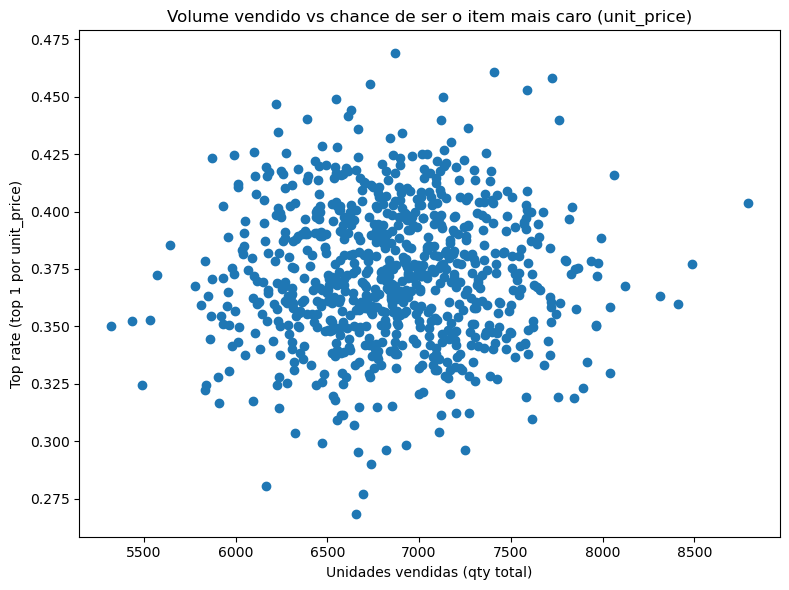

In [14]:

products    = pd.read_csv(_csv_path('products.csv'))
order_items = pd.read_csv(_csv_path('order_items.csv'))
orders      = pd.read_csv(_csv_path('orders.csv'))

# (Opcional) parse de data
if "created_at" in orders.columns:
    orders["created_at"] = pd.to_datetime(orders["created_at"], errors="coerce")

# Join order_items + orders (para ter status/data se quiser filtrar depois)
oi = order_items.merge(
    orders[["id", "status", "created_at"]],
    left_on="order_id",
    right_on="id",
    how="left",
    suffixes=("", "_order")
).drop(columns=["id_order"])

# Unidades vendidas por produto
units = (
    oi.groupby("product_id", as_index=False)["qty"]
      .sum()
      .rename(columns={"qty": "units_sold"})
)

# ROW_NUMBER por pedido: item mais caro por unit_price (desempate por product_id)
oi_sorted = oi.sort_values(
    ["order_id", "unit_price", "product_id"],
    ascending=[True, False, True]
).copy()

oi_sorted["rn_unit_price"] = oi_sorted.groupby("order_id").cumcount() + 1
oi_sorted["is_top_by_unit_price"] = oi_sorted["rn_unit_price"].eq(1)

# Quantos pedidos cada produto aparece
orders_with_product = (
    oi_sorted.groupby("product_id")["order_id"]
            .nunique()
            .reset_index(name="orders_with_product")
)

# Quantos pedidos ele foi top 1 por unit_price
top_counts = (
    oi_sorted.loc[oi_sorted["is_top_by_unit_price"], ["product_id", "order_id"]]
            .groupby("product_id")["order_id"]
            .nunique()
            .reset_index(name="top_orders_count")
)

# Consolida métricas
metrics = (
    units.merge(orders_with_product, on="product_id", how="left")
         .merge(top_counts, on="product_id", how="left")
)

metrics["top_orders_count"] = metrics["top_orders_count"].fillna(0).astype(int)
metrics["top_rate"] = metrics["top_orders_count"] / metrics["orders_with_product"]

# Adiciona info do produto
metrics = (
    metrics.merge(
        products[["id", "name", "category", "seller_id"]],
        left_on="product_id",
        right_on="id",
        how="left"
    )
    .drop(columns=["id"])
)

# Candidatos do desafio (se existirem): vende muito e nunca é top por unit_price
candidates = metrics[(metrics["units_sold"] > 1000) & (metrics["top_orders_count"] == 0)]
display(candidates.sort_values("units_sold", ascending=False).head(20))

# Gráfico: 20 produtos com menor top_rate
plot_df = metrics.sort_values(["top_rate", "orders_with_product"], ascending=[True, False]).head(20)
plot_df = plot_df.sort_values("top_rate", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["name"], plot_df["top_rate"])
plt.xlabel("Proporção de pedidos em que foi o item mais caro (unit_price)")
plt.ylabel("Produto (20 menores proporções)")
plt.title("Produtos que raramente são o item mais caro do pedido (unit_price)")
plt.tight_layout()
plt.show()

# Extra: scatter (volume vs chance de ser top)
plt.figure(figsize=(8, 6))
plt.scatter(metrics["units_sold"], metrics["top_rate"])
plt.xlabel("Unidades vendidas (qty total)")
plt.ylabel("Top rate (top 1 por unit_price)")
plt.title("Volume vendido vs chance de ser o item mais caro (unit_price)")
plt.tight_layout()
plt.show()

**1) “Maior” por unit_price (preço unitário)**

**Gráfico de barras (20 menores top_rate):** mesmo os produtos que raramente são o mais caro por unidade ainda aparecem como #1 em cerca de 27% a 31% dos pedidos em que participam.
→ Ou seja, não existem produtos com top_rate = 0 (nunca serem o mais caro) no seu dataset.

**Scatter (units_sold vs top_rate):** a nuvem é bem espalhada, indicando ausência de correlação forte entre volume total vendido e chance de ser o item mais caro por unidade.
→ Vender mais no agregado não implica ser mais caro dentro do carrinho.

**Interpretação: “Ser o mais caro” por unit_price depende mais do posicionamento de preço e do mix do pedido do que do volume.**

### Resumo da análise gráfica - “Maior” por item_total = qty * unit_price - discount (valor total do item)

,product_id,units_sold,orders_with_product,top_orders_count,top_rate,name,category,seller_id


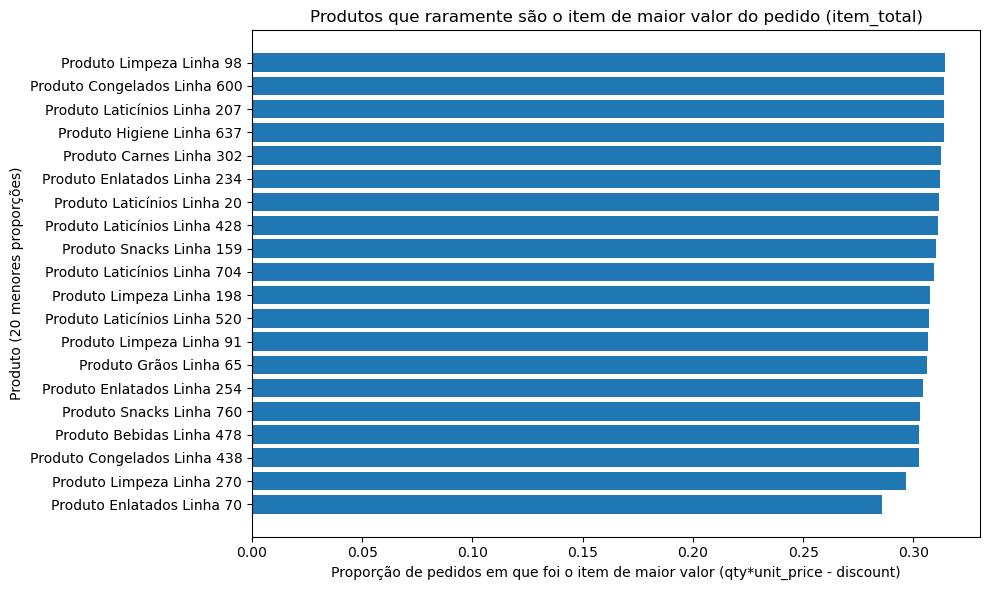

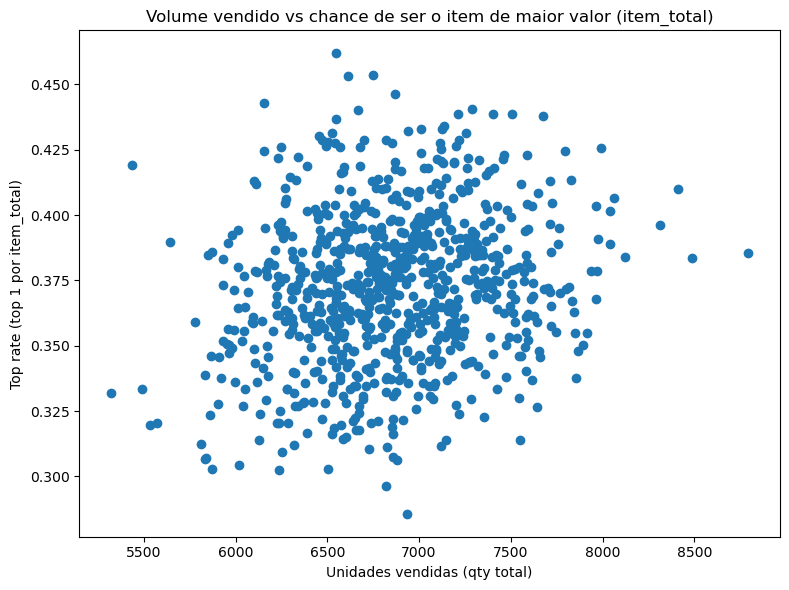

In [15]:
products    = pd.read_csv(_csv_path('products.csv'))
order_items = pd.read_csv(_csv_path('order_items.csv'))
orders      = pd.read_csv(_csv_path('orders.csv'))

# Join order_items + orders
oi = order_items.merge(
    orders[["id", "status", "created_at"]],
    left_on="order_id",
    right_on="id",
    how="left",
    suffixes=("", "_order")
).drop(columns=["id_order"])

# Garante discount numérico (caso tenha NaN)
oi["discount"] = oi["discount"].fillna(0)

# Unidades vendidas por produto
units = (
    oi.groupby("product_id", as_index=False)["qty"]
      .sum()
      .rename(columns={"qty": "units_sold"})
)

# ====== NOVO: valor total do item no pedido ======
oi["item_total"] = (oi["qty"] * oi["unit_price"]) - oi["discount"]

# ROW_NUMBER por pedido (item de maior VALOR TOTAL; desempate por product_id)
oi_sorted = oi.sort_values(
    ["order_id", "item_total", "product_id"],
    ascending=[True, False, True]
).copy()

oi_sorted["rn_item_total"] = oi_sorted.groupby("order_id").cumcount() + 1
oi_sorted["is_top_by_item_total"] = oi_sorted["rn_item_total"].eq(1)

# Quantos pedidos o produto aparece
orders_with_product = (
    oi_sorted.groupby("product_id")["order_id"]
            .nunique()
            .reset_index(name="orders_with_product")
)

# Quantos pedidos ele foi top 1 por item_total
top_counts = (
    oi_sorted.loc[oi_sorted["is_top_by_item_total"], ["product_id", "order_id"]]
            .groupby("product_id")["order_id"]
            .nunique()
            .reset_index(name="top_orders_count")
)

# Consolida métricas
metrics = (
    units.merge(orders_with_product, on="product_id", how="left")
         .merge(top_counts, on="product_id", how="left")
)

metrics["top_orders_count"] = metrics["top_orders_count"].fillna(0).astype(int)
metrics["top_rate"] = metrics["top_orders_count"] / metrics["orders_with_product"]

# Adiciona info do produto
metrics = (
    metrics.merge(
        products[["id", "name", "category", "seller_id"]],
        left_on="product_id",
        right_on="id",
        how="left"
    )
    .drop(columns=["id"])
)

# Candidatos do desafio (se existirem): vende muito e nunca é top por item_total
candidates = metrics[(metrics["units_sold"] > 1000) & (metrics["top_orders_count"] == 0)]
display(candidates.sort_values("units_sold", ascending=False).head(20))

# Gráfico: 20 produtos com menor top_rate
plot_df = metrics.sort_values(["top_rate", "orders_with_product"], ascending=[True, False]).head(20)
plot_df = plot_df.sort_values("top_rate", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["name"], plot_df["top_rate"])
plt.xlabel("Proporção de pedidos em que foi o item de maior valor (qty*unit_price - discount)")
plt.ylabel("Produto (20 menores proporções)")
plt.title("Produtos que raramente são o item de maior valor do pedido (item_total)")
plt.tight_layout()
plt.show()

# Extra: scatter (volume vs chance de ser top)
plt.figure(figsize=(8, 6))
plt.scatter(metrics["units_sold"], metrics["top_rate"])
plt.xlabel("Unidades vendidas (qty total)")
plt.ylabel("Top rate (top 1 por item_total)")
plt.title("Volume vendido vs chance de ser o item de maior valor (item_total)")
plt.tight_layout()
plt.show()

**2) “Maior” por item_total = qty * unit_price - discount (valor total do item)**

**Gráfico de barras (20 menores top_rate):** novamente, os “piores” ainda têm top_rate perto de ~29% a 32%.
→ Continua sem aparecer o caso extremo de “nunca lidera”.

**Scatter (units_sold vs top_rate):** segue sem uma tendência clara; no máximo uma leve inclinação positiva, mas fraca.
→ O fator decisivo aqui é o comportamento por pedido (qty e desconto), não o volume total do período.

**Interpretação: quando o critério é item_total, quem ganha dentro do pedido pode ser um item com preço médio, mas quantidade alta e/ou desconto baixo.**

## Prova Diagnóstica - Desafio 4

In [16]:
%%time
# Bloco 14
# --- Prova / Diagnóstico (Desafio 4) ---
query_prova_desafio_4 = """
WITH valid_items AS (
  SELECT
    oi.order_id,
    oi.product_id,
    oi.qty,
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),

top_products AS (
  -- T = produtos que já foram top unitário (considerando empates)
  SELECT DISTINCT product_id
  FROM (
    SELECT
      order_id,
      product_id,
      RANK() OVER (PARTITION BY order_id ORDER BY unit_price DESC) AS rnk
    FROM valid_items
  ) x
  WHERE rnk = 1
),

universe_products AS (
  -- U = produtos que aparecem em pedidos válidos
  SELECT DISTINCT product_id
  FROM valid_items
)

SELECT
  (SELECT COUNT(*) FROM universe_products) AS total_products_valid,          -- |U|
  (SELECT COUNT(*) FROM top_products) AS products_that_were_max,             -- |T|
  (SELECT COUNT(*)
   FROM top_products tp
   LEFT JOIN universe_products up
     ON up.product_id = tp.product_id
   WHERE up.product_id IS NULL) AS top_not_in_universe,                      -- prova T ⊆ U (esperado 0)
  (SELECT COUNT(*)
   FROM universe_products up
   LEFT JOIN top_products tp
     ON tp.product_id = up.product_id
   WHERE tp.product_id IS NULL) AS universe_not_in_top                        -- |U \ T| (se 0 => U = T)
;
"""

df_prova = pd.read_sql_query(query_prova_desafio_4, engine)
display(df_prova)

u = int(df_prova.loc[0, "total_products_valid"])
t = int(df_prova.loc[0, "products_that_were_max"])
t_not_subset = int(df_prova.loc[0, "top_not_in_universe"])
u_minus_t = int(df_prova.loc[0, "universe_not_in_top"])

# Gera texto em Markdown automaticamente com os números do resultado
md_conclusao = f"""
## Conclusão / justificativa Matemática (resultado vazio)

Pelos dados filtrados em pedidos válidos (`status NOT IN ('cancelled','refunded')`), definimos:

- **U** = conjunto de produtos que aparecem em pedidos válidos  
- **T** = conjunto de produtos que **já foram** o item de maior `unit_price` em algum pedido válido (considerando empates via `RANK()`)

O diagnóstico retornou:

- \\|U\\| = **{u}**
- \\|T\\| = **{t}**
- **top_not_in_universe = {t_not_subset}** → confirma que **T ⊆ U**
- \\|U \\ T\\| = **{u_minus_t}**

Como **T ⊆ U** e **\\|U\\| = \\|T\\|**, então **T = U**.  
Logo, **\\|U \\ T\\| = 0**, isto é, **não existe nenhum `product_id` que nunca tenha sido “top unitário”** em pedidos válidos.

Portanto, **não existe produto** que satisfaça simultaneamente:

1. `total_unidades > 1000`, e  
2. **nunca** ter sido o item de maior `unit_price` em nenhum pedido válido.

✅ Conclusão: a query do **Desafio 4** está correta e o **retorno vazio é esperado** dada a distribuição do dataset (alinhado à orientação do enunciado sobre avaliar a viabilidade do resultado).
"""

# print(md_conclusao)

,total_products_valid,products_that_were_max,top_not_in_universe,universe_not_in_top
0,800,800,0,0


CPU times: total: 1.47 s
Wall time: 1.53 s


In [17]:
%%time
# Bloco 15
from IPython.display import Markdown, display
display(Markdown(md_conclusao))


## Conclusão / justificativa Matemática (resultado vazio)

Pelos dados filtrados em pedidos válidos (`status NOT IN ('cancelled','refunded')`), definimos:

- **U** = conjunto de produtos que aparecem em pedidos válidos  
- **T** = conjunto de produtos que **já foram** o item de maior `unit_price` em algum pedido válido (considerando empates via `RANK()`)

O diagnóstico retornou:

- \|U\| = **800**
- \|T\| = **800**
- **top_not_in_universe = 0** → confirma que **T ⊆ U**
- \|U \ T\| = **0**

Como **T ⊆ U** e **\|U\| = \|T\|**, então **T = U**.  
Logo, **\|U \ T\| = 0**, isto é, **não existe nenhum `product_id` que nunca tenha sido “top unitário”** em pedidos válidos.

Portanto, **não existe produto** que satisfaça simultaneamente:

1. `total_unidades > 1000`, e  
2. **nunca** ter sido o item de maior `unit_price` em nenhum pedido válido.

✅ Conclusão: a query do **Desafio 4** está correta e o **retorno vazio é esperado** dada a distribuição do dataset (alinhado à orientação do enunciado sobre avaliar a viabilidade do resultado).


CPU times: total: 0 ns
Wall time: 1.8 ms


## Proposta de solução amostral para o Desafio 4

## Desafio 4 (reescrito) — Produto com alto volume, mas “raramente top unitário” no pedido

### Objetivo

Encontrar produtos com **total de unidades vendidas > 1000** que foram o item de **maior valor unitário (`unit_price`)** em **no máximo 30%** dos pedidos em que apareceram.

### Observação importante de negócio

* O enunciado original (“**nunca foi top**”) é **inviável neste dataset** (todos os produtos acabam sendo top em algum pedido).
* Aqui relaxamos a regra para “**raramente top**” (≤ 30%), mantendo a ideia de produto com alto volume que normalmente não é o mais caro do pedido.
* **Empates contam como “foi top”** (`unit_price = MAX(unit_price)` do pedido).

### Estratégia

1. Filtrar pedidos válidos (evitar `cancelled` / `refunded`).
2. Calcular, por produto: **total de unidades vendidas** (> 1000).
3. Calcular, por produto: **nº de pedidos em que apareceu** (denominador).
4. Calcular, por produto: **nº de pedidos em que foi top unitário** (numerador).
5. Filtrar **`pct_top <= 0.30`** e ordenar por unidades vendidas.


In [18]:
%%time
# Bloco 16
# --- Desafio 4 (reescrito) — Produto com alto volume, mas "raramente top unitário" no pedido ---

query_desafio_4_reescrito = """
-- Objetivo (Desafio 4 reescrito):
-- Produtos com total_unidades > 1000 que foram top unitário (maior unit_price do pedido)
-- em no máximo 30% dos pedidos em que apareceram.

WITH valid_items AS (
  -- 1) Early filter: mantém apenas pedidos válidos e colunas necessárias
  SELECT
    oi.order_id,
    oi.product_id,
    oi.qty,
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),

sold AS (
  -- 2) Volume por produto (filtro de negócio)
  SELECT
    product_id,
    SUM(qty) AS units_sold
  FROM valid_items
  GROUP BY product_id
  HAVING SUM(qty) > 1000
),

prod_orders AS (
  -- 3) Denominador: em quantos pedidos o produto apareceu
  SELECT
    product_id,
    COUNT(DISTINCT order_id) AS n_orders
  FROM valid_items
  GROUP BY product_id
),

prod_orders_as_max AS (
  -- 4) Numerador: em quantos pedidos o produto foi top unitário
  --    - empate conta como top (unit_price = max_unit_price)
  SELECT
    vi.product_id,
    COUNT(DISTINCT vi.order_id) AS n_orders_as_max
  FROM valid_items vi
  JOIN (
    SELECT
      order_id,
      MAX(unit_price) AS max_unit_price
    FROM valid_items
    GROUP BY order_id
  ) m
    ON m.order_id = vi.order_id
   AND vi.unit_price = m.max_unit_price
  GROUP BY vi.product_id
)

-- 5) Resultado final:
--    - junta volume (sold) + denominador (prod_orders) + numerador (prod_orders_as_max)
--    - filtra pct_top <= 30%
--    - join com products só no final (dimensão)
SELECT
  p.id        AS product_id,
  p.name      AS product_nome,
  p.category  AS categoria,
  s.units_sold,
  po.n_orders,
  COALESCE(pm.n_orders_as_max, 0) AS n_orders_as_max,
  (COALESCE(pm.n_orders_as_max, 0) * 1.0 / po.n_orders) AS pct_orders_as_max
FROM sold s
JOIN prod_orders po
  ON po.product_id = s.product_id
LEFT JOIN prod_orders_as_max pm
  ON pm.product_id = s.product_id
JOIN products p
  ON p.id = s.product_id
WHERE (COALESCE(pm.n_orders_as_max, 0) * 1.0 / po.n_orders) <= 0.30
ORDER BY s.units_sold DESC;
"""

df_desafio_4_reescrito = pd.read_sql_query(query_desafio_4_reescrito, engine)
df_desafio_4_reescrito

CPU times: total: 3.83 s
Wall time: 3.83 s


,product_id,product_nome,categoria,units_sold,n_orders,n_orders_as_max,pct_orders_as_max
0,729,Produto Enlatados Linha 729,Limpeza,6478,249,72,0.289157
1,20,Produto Laticínios Linha 20,Limpeza,6135,251,74,0.294821
2,375,Produto Laticínios Linha 375,Bebidas,6086,251,75,0.298805
3,290,Produto Laticínios Linha 290,Limpeza,5928,234,70,0.299145
4,539,Produto Enlatados Linha 539,Laticínios,5821,225,64,0.284444
5,270,Produto Limpeza Linha 270,Padaria,5776,243,71,0.292181
6,615,Produto Limpeza Linha 615,Carnes,5724,228,63,0.276316
7,736,Produto Padaria Linha 736,Congelados,5670,219,58,0.264840
8,746,Produto Laticínios Linha 746,Padaria,5547,228,68,0.298246
9,350,Produto Limpeza Linha 350,Limpeza,5261,214,56,0.261682


> “O dataset tem comportamento em que muitos produtos assumem o topo de `unit_price` com frequência; por isso o corte de 30% seleciona apenas a cauda inferior da distribuição de `pct_orders_as_max`.”


## Análise grafica - Distribuição da proporção de vezes que o produto é o mais caro no pedido (pct_orders_as_max) 

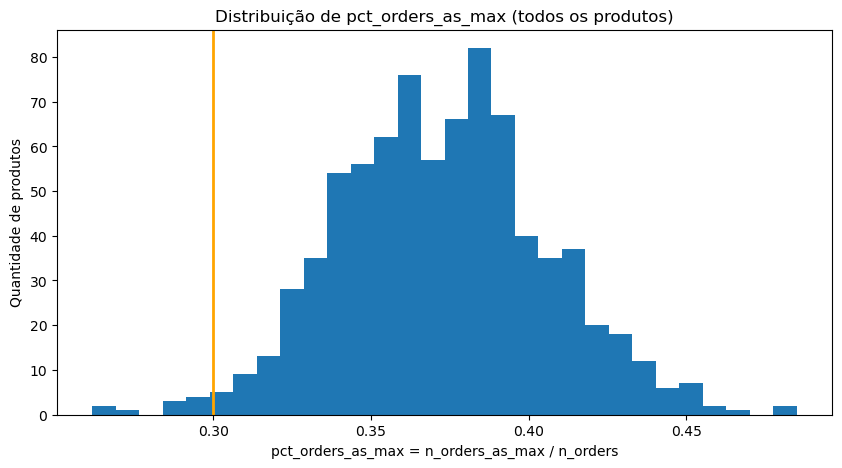

Produtos com pct_orders_as_max <= 0.30: 11 de 800 (1.38%)
Resumo estatístico:


count    800.000000
mean       0.372688
std        0.032917
min        0.261682
5%         0.322700
10%        0.331945
25%        0.349952
50%        0.372807
75%        0.393213
90%        0.415638
95%        0.427382
max        0.484979
Name: pct_orders_as_max, dtype: float64

CPU times: total: 3.47 s
Wall time: 3.46 s


In [19]:
%%time
# Bloco 17
# --- Distribuição de pct_orders_as_max (TODOS os produtos) ---
# pct_orders_as_max = (nº de pedidos em que o produto foi top unit_price) / (nº de pedidos em que o produto apareceu)

# Query SQL para calcular, por produto:
# - n_orders: em quantos pedidos válidos o produto apareceu
# - n_orders_as_max: em quantos desses pedidos ele foi o item com maior unit_price (empate conta)
# - pct_orders_as_max: n_orders_as_max / n_orders
query_pct_all = """
WITH valid_items AS (
  -- Seleciona itens de pedidos considerados "válidos"
  -- (exclui pedidos cancelados e reembolsados)
  SELECT
    oi.order_id,
    oi.product_id,
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),

prod_orders AS (
  -- Para cada produto, conta em quantos pedidos distintos ele apareceu
  SELECT
    product_id,
    COUNT(DISTINCT order_id) AS n_orders
  FROM valid_items
  GROUP BY product_id
),

prod_orders_as_max AS (
  -- Para cada produto, conta em quantos pedidos ele aparece com unit_price igual ao máximo do pedido
  -- Observação: se houver empate no maior preço do pedido, todos os empatados contam como "foi top"
  SELECT
    vi.product_id,
    COUNT(DISTINCT vi.order_id) AS n_orders_as_max
  FROM valid_items vi
  JOIN (
    -- Calcula o maior unit_price dentro de cada pedido
    SELECT
      order_id,
      MAX(unit_price) AS max_unit_price
    FROM valid_items
    GROUP BY order_id
  ) m
    ON m.order_id = vi.order_id
   AND vi.unit_price = m.max_unit_price  -- empate conta como "foi top"
  GROUP BY vi.product_id
)

-- Junta as duas contagens e calcula a proporção final
SELECT
  po.product_id,
  po.n_orders,
  COALESCE(pm.n_orders_as_max, 0) AS n_orders_as_max,          -- se não tiver "top", vira 0
  (COALESCE(pm.n_orders_as_max, 0) * 1.0 / po.n_orders) AS pct_orders_as_max  -- força divisão float
FROM prod_orders po
LEFT JOIN prod_orders_as_max pm
  ON pm.product_id = po.product_id;
"""

# Executa a query SQL e traz o resultado para um DataFrame pandas
df_pct_all = pd.read_sql_query(query_pct_all, engine)

# --- Gráfico: histograma + linha de corte 30% ---

# Extrai a coluna de interesse, remove nulos e garante tipo float
vals = df_pct_all["pct_orders_as_max"].dropna().astype(float)

# Cria a figura do gráfico com tamanho 10x5
plt.figure(figsize=(10, 5))

# Histograma da distribuição (30 bins = 30 “faixas”)
plt.hist(vals, bins=30)

# Linha vertical em 0.30 para marcar o “corte” de 30%
plt.axvline(0.30, color='orange', linewidth=2)

# Título e labels dos eixos
plt.title("Distribuição de pct_orders_as_max (todos os produtos)")
plt.xlabel("pct_orders_as_max = n_orders_as_max / n_orders")
plt.ylabel("Quantidade de produtos")

# Renderiza o gráfico
plt.show()

# --- Métricas rápidas para sustentar a frase da justificativa ---

# Define o valor de corte (30%)
cut = 0.30

# Conta quantos produtos têm pct <= 0.30
tail_count = (vals <= cut).sum()

# Total de produtos considerados (com valor não-nulo)
total = len(vals)

# Imprime quantidade e percentual de produtos abaixo/igual ao corte
print(f"Produtos com pct_orders_as_max <= {cut:.2f}: {tail_count} de {total} ({tail_count/total:.2%})")

# Imprime estatísticas descritivas e percentis para embasar análise
print("Resumo estatístico:")
display(vals.describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]))

## Seleção do melhor ponto de corte para segmentação de produtos (Lift de GMV)

Melhor t por LIFT (GMV médio):
t                3.318594e-01
n_low            7.800000e+01
n_high           7.220000e+02
mean_gmv_low     1.416811e+06
mean_gmv_high    1.474893e+06
lift_mean_gmv    4.099520e-02
Name: 7, dtype: float64

Melhor t por ΔGMV total (high - low):
t                  3.226997e-01
n_low              4.000000e+01
n_high             7.600000e+02
gmv_low_total      5.682206e+07
gmv_high_total     1.118562e+09
delta_total_gmv    1.061740e+09
Name: 0, dtype: float64


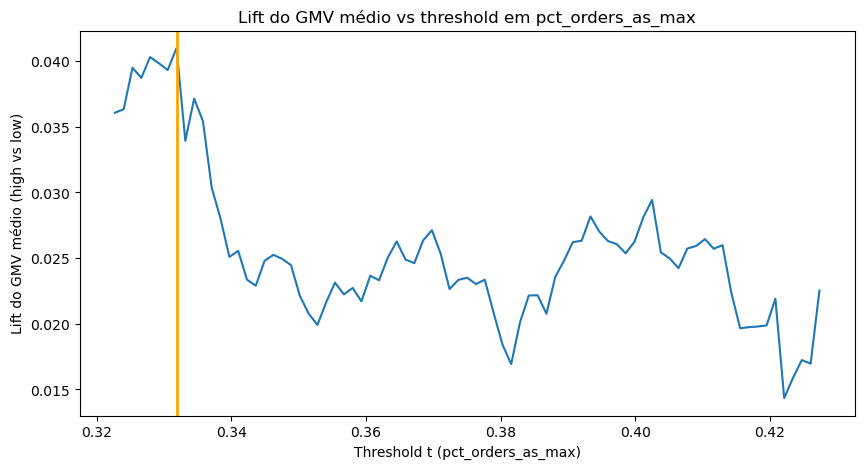

CPU times: total: 3.69 s
Wall time: 3.7 s


In [20]:
%%time
# Bloco 18
# -----------------------------
# 1) SQL: calcula métricas por produto
#    - n_orders: nº de pedidos (válidos) em que o produto apareceu
#    - n_orders_as_max: nº de pedidos em que o produto teve o maior unit_price (empate conta)
#    - pct_orders_as_max: n_orders_as_max / n_orders
#    - gmv: total vendido do produto (qty * unit_price) em pedidos válidos
# -----------------------------
query = """
WITH valid_items AS (
  -- Itens de pedidos válidos (remove pedidos cancelados e reembolsados)
  SELECT
    oi.order_id,
    oi.product_id,
    oi.qty AS quantity,        -- renomeia qty -> quantity para facilitar leitura
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),
prod_orders AS (
  -- Por produto: quantos pedidos distintos ele apareceu + GMV total do produto
  SELECT
    product_id,
    COUNT(DISTINCT order_id) AS n_orders,
    SUM(quantity * unit_price) AS gmv
  FROM valid_items
  GROUP BY product_id
),
prod_orders_as_max AS (
  -- Por produto: em quantos pedidos ele aparece com unit_price igual ao máximo do pedido
  SELECT
    vi.product_id,
    COUNT(DISTINCT vi.order_id) AS n_orders_as_max
  FROM valid_items vi
  JOIN (
    -- Calcula o maior unit_price por pedido
    SELECT order_id, MAX(unit_price) AS max_unit_price
    FROM valid_items
    GROUP BY order_id
  ) m
    ON m.order_id = vi.order_id
   AND vi.unit_price = m.max_unit_price   -- empate no maior preço também conta
  GROUP BY vi.product_id
)
-- Junta as tabelas e calcula a proporção pct_orders_as_max
SELECT
  po.product_id,
  po.n_orders,
  COALESCE(pm.n_orders_as_max, 0) AS n_orders_as_max,                         -- se não tiver, vira 0
  (COALESCE(pm.n_orders_as_max, 0) * 1.0 / po.n_orders) AS pct_orders_as_max, -- 1.0 força divisão float
  po.gmv
FROM prod_orders po
LEFT JOIN prod_orders_as_max pm
  ON pm.product_id = po.product_id;
"""

# Executa a query e traz para um DataFrame
df = pd.read_sql_query(query, engine)

# -----------------------------
# 2) Pré-filtro (evita ruído)
# -----------------------------
# Garante tipos numéricos para as métricas usadas no cálculo/plot
df["pct_orders_as_max"] = df["pct_orders_as_max"].astype(float)
df["gmv"] = df["gmv"].astype(float)

min_orders = 30  # mínimo de pedidos por produto para reduzir outliers/instabilidade
# Mantém apenas produtos com volume suficiente e pct não nulo
dfv = df[(df["n_orders"] >= min_orders) & (df["pct_orders_as_max"].notna())].copy()

# -----------------------------
# 3) Varredura de thresholds (t)
#    mede impacto de vendas (GMV) ao separar produtos em low vs high
# -----------------------------
# Cria 81 thresholds entre o P5 e o P95 do score (evita extremos)
thresholds = np.linspace(
    dfv["pct_orders_as_max"].quantile(0.05),
    dfv["pct_orders_as_max"].quantile(0.95),
    81
)

rows = []
for t in thresholds:
    # Divide os produtos em dois grupos pelo corte t
    low = dfv[dfv["pct_orders_as_max"] <= t]
    high = dfv[dfv["pct_orders_as_max"] > t]

    # Evita cortes que deixem um grupo muito pequeno (resultados instáveis)
    if len(low) < 20 or len(high) < 20:
        continue

    # GMV total por grupo (soma dos produtos do grupo)
    gmv_low = low["gmv"].sum()
    gmv_high = high["gmv"].sum()

    # GMV médio por produto em cada grupo (média dos produtos do grupo)
    mean_gmv_low = low["gmv"].mean()
    mean_gmv_high = high["gmv"].mean()

    # Lift (GMV médio): quanto o grupo high é maior que low, em proporção
    # Ex.: 0.04 = high vende 4% a mais (em média por produto)
    lift_mean = (mean_gmv_high / mean_gmv_low) - 1 if mean_gmv_low > 0 else np.nan

    # Guarda resultados do threshold t
    rows.append({
        "t": float(t),
        "n_low": int(len(low)),
        "n_high": int(len(high)),
        "gmv_low_total": float(gmv_low),
        "gmv_high_total": float(gmv_high),
        "mean_gmv_low": float(mean_gmv_low),
        "mean_gmv_high": float(mean_gmv_high),
        "lift_mean_gmv": float(lift_mean),
        "delta_total_gmv": float(gmv_high - gmv_low),  # diferença absoluta de GMV total
    })

# DataFrame final com os thresholds testados
res = pd.DataFrame(rows).sort_values("t").reset_index(drop=True)

# -----------------------------
# 4) Encontra “melhores” cortes
# -----------------------------
# Melhor corte para maximizar o lift do GMV médio
best_by_lift = res.loc[res["lift_mean_gmv"].idxmax()]

# Melhor corte para maximizar a diferença absoluta de GMV total (high - low)
best_by_delta_total = res.loc[res["delta_total_gmv"].idxmax()]

print("Melhor t por LIFT (GMV médio):")
print(best_by_lift[["t","n_low","n_high","mean_gmv_low","mean_gmv_high","lift_mean_gmv"]])

print("\nMelhor t por ΔGMV total (high - low):")
print(best_by_delta_total[["t","n_low","n_high","gmv_low_total","gmv_high_total","delta_total_gmv"]])

# -----------------------------
# 5) Gráfico para visualizar o lift ao longo dos thresholds
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(res["t"], res["lift_mean_gmv"])           # curva do lift em função do threshold
plt.axvline(best_by_lift["t"], color='orange', linewidth=2)      # marca o melhor t por lift
plt.title("Lift do GMV médio vs threshold em pct_orders_as_max")
plt.xlabel("Threshold t (pct_orders_as_max)")
plt.ylabel("Lift do GMV médio (high vs low)")
plt.show()

**Testamos diferentes thresholds para pct_orders_as_max e observamos que o corte em t≈0,332 maximiza o lift do GMV médio: produtos acima desse valor apresentam ~4,1% maior GMV médio por produto em comparação aos abaixo do corte.**

#### Observe: Acima de ~33% dos pedidos como ‘mais caro’, os produtos tendem a ter GMV médio maior.

**Nota: Lift = quanto o grupo “high” vende a mais que o “low” (em %).**

In [21]:
%%time
# Mede e imprime o tempo TOTAL de execução desta célula (CPU + wall time),
# útil para comparar performance antes/depois de otimizações.
# Bloco 19

# Ajustes sugeridos (parâmetros “de negócio”/filtro):
# - MIN_UNITS: define um corte mínimo de unidades vendidas para considerar o produto.
#   Isso evita que produtos com pouquíssimas vendas distorçam a análise.
# - MAX_PCT_TOP: limite máximo permitido para a proporção de pedidos em que o produto
#   aparece como o item MAIS CARO do pedido. Quanto menor, mais restritivo.
MIN_UNITS = 1000      # ou 10000, ou use percentil
MAX_PCT_TOP = 0.3319  # 0.33 (mais restrito) | 0.35 (mais razoável) | 0.30 (muito restrito)

# Monta a query SQL com f-string para injetar os parâmetros acima
query_desafio_4_reescrito = f"""
WITH valid_items AS (
  -- Base “limpa”: itens de pedidos válidos (exclui cancelados e reembolsados).
  -- Mantém apenas colunas necessárias para reduzir custo.
  SELECT
    oi.order_id,
    oi.product_id,
    oi.qty,
    oi.unit_price
  FROM order_items oi
  JOIN orders o
    ON o.id = oi.order_id
   AND o.status NOT IN ('cancelled', 'refunded')
),

sold AS (
  -- Soma unidades vendidas por produto.
  -- HAVING filtra só produtos que passaram do MIN_UNITS.
  SELECT
    product_id,
    SUM(qty) AS units_sold
  FROM valid_items
  GROUP BY product_id
  HAVING SUM(qty) > {MIN_UNITS}
),

prod_orders AS (
  -- Conta em quantos pedidos distintos cada produto apareceu.
  -- É o denominador para calcular a % de vezes que foi “o mais caro”.
  SELECT
    product_id,
    COUNT(DISTINCT order_id) AS n_orders
  FROM valid_items
  GROUP BY product_id
),

prod_orders_as_max AS (
  -- Conta em quantos pedidos cada produto foi o item de MAIOR unit_price.
  -- 1) Subquery m calcula o max_unit_price por pedido.
  -- 2) Junta com valid_items para pegar quais produtos têm unit_price == max_unit_price.
  -- Observação: se houver empate (dois itens com mesmo unit_price máximo),
  -- ambos contam para n_orders_as_max.
  SELECT
    vi.product_id,
    COUNT(DISTINCT vi.order_id) AS n_orders_as_max
  FROM valid_items vi
  JOIN (
    SELECT
      order_id,
      MAX(unit_price) AS max_unit_price
    FROM valid_items
    GROUP BY order_id
  ) m
    ON m.order_id = vi.order_id
   AND vi.unit_price = m.max_unit_price
  GROUP BY vi.product_id
)

-- Seleção final: traz dados do produto e métricas calculadas
SELECT
  p.id        AS product_id,
  p.name      AS product_nome,
  p.category  AS categoria,
  s.units_sold,
  po.n_orders,
  COALESCE(pm.n_orders_as_max, 0) AS n_orders_as_max,

  -- Percentual de pedidos em que o produto foi o item mais caro.
  -- Multiplica por 1.0 para forçar divisão em float (evita divisão inteira).
  (COALESCE(pm.n_orders_as_max, 0) * 1.0 / po.n_orders) AS pct_orders_as_max
FROM sold s
JOIN prod_orders po
  ON po.product_id = s.product_id
LEFT JOIN prod_orders_as_max pm
  ON pm.product_id = s.product_id
JOIN products p
  ON p.id = s.product_id

-- Filtro principal: mantém apenas produtos cuja % de “mais caro” é <= MAX_PCT_TOP
WHERE (COALESCE(pm.n_orders_as_max, 0) * 1.0 / po.n_orders) <= {MAX_PCT_TOP}

-- Ordena pelos mais vendidos (entre os que passaram nos filtros)
ORDER BY s.units_sold DESC;
"""

# Executa a query no banco (via SQLAlchemy engine) e retorna em um DataFrame pandas
df_desafio_4_reescrito = pd.read_sql_query(query_desafio_4_reescrito, engine)

# Exibe o resultado final
df_desafio_4_reescrito


CPU times: total: 3.8 s
Wall time: 3.8 s


,product_id,product_nome,categoria,units_sold,n_orders,n_orders_as_max,pct_orders_as_max
0,289,Produto Grãos Linha 289,Limpeza,7019,255,79,0.309804
1,582,Produto Enlatados Linha 582,Bebidas,6662,250,78,0.312000
2,21,Produto Higiene Linha 21,Higiene,6660,251,77,0.306773
3,467,Produto Grãos Linha 467,Padaria,6612,244,74,0.303279
4,295,Produto Snacks Linha 295,Laticínios,6523,243,80,0.329218
...,...,...,...,...,...,...,...
75,491,Produto Bebidas Linha 491,Congelados,5108,208,68,0.326923
76,520,Produto Laticínios Linha 520,Carnes,5084,198,65,0.328283
77,438,Produto Congelados Linha 438,Carnes,5007,200,58,0.290000
78,244,Produto Carnes Linha 244,Padaria,4883,208,67,0.322115


## Atenção: A solução acima deve ser avaliada junto ao time de negócios

## Análise temporal (tempo por célula)
Os gráficos abaixo são gerados a partir dos tempos coletados automaticamente durante a execução do notebook.


,exec_order,seconds,first_line,n_lines,cum_seconds
0,1,0.000000,,0,0.000000
1,2,0.003199,%%time,10,0.003199
2,3,1.710850,%%time,85,1.714049
3,4,0.015171,%%time,8,1.729220
4,5,0.210618,%%time,91,1.939838
5,6,0.010859,%%time,8,1.950697
6,7,0.477699,%%time,149,2.428396
7,8,0.014538,%%time,8,2.442934
8,9,0.485598,%%time,82,2.928532
9,10,0.009611,%%time,8,2.938143


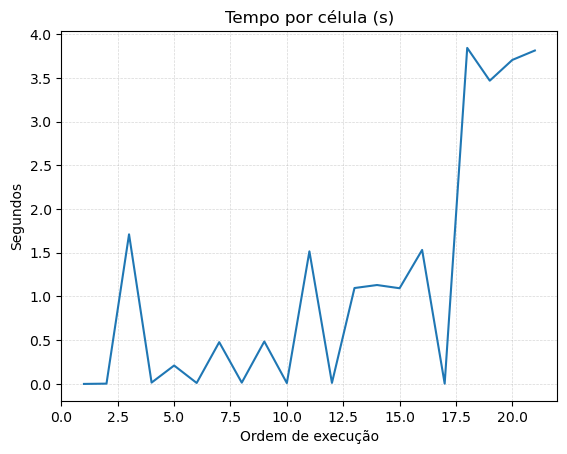

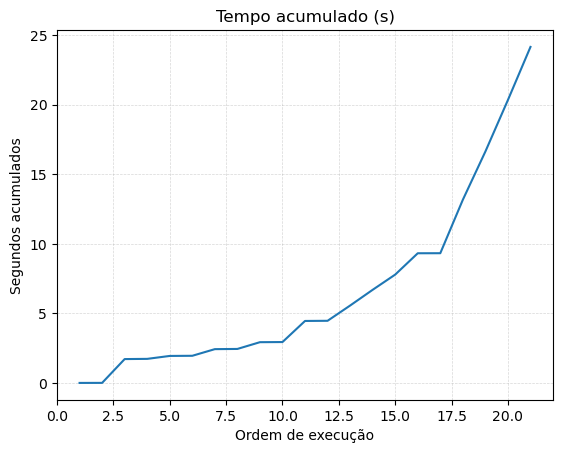

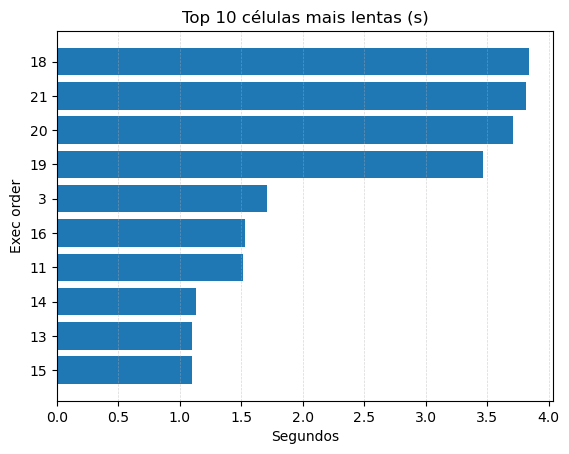

Tempo total medido (s): 24.1554


In [22]:
# Bloco 20
df_times = pd.DataFrame(__cell_times__).copy()

# Se o notebook ainda não foi executado (lista vazia), avisa.
if df_times.empty:
    print("Nenhuma célula foi executada ainda nesta sessão — execute o notebook e rode novamente esta célula.")
else:
    df_times["seconds"] = pd.to_numeric(df_times["seconds"], errors="coerce")
    df_times["cum_seconds"] = df_times["seconds"].cumsum()

    display(df_times)

    # Linha: tempo por célula
    plt.figure()
    plt.plot(df_times["exec_order"], df_times["seconds"])
    plt.title("Tempo por célula (s)")
    plt.xlabel("Ordem de execução")
    plt.ylabel("Segundos")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.show()

    # Linha: tempo acumulado
    plt.figure()
    plt.plot(df_times["exec_order"], df_times["cum_seconds"])
    plt.title("Tempo acumulado (s)")
    plt.xlabel("Ordem de execução")
    plt.ylabel("Segundos acumulados")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.show()

    # Barras: Top 10 células mais lentas
    top = df_times.sort_values("seconds", ascending=False).head(10).sort_values("seconds", ascending=True)
    plt.figure()
    plt.barh(top["exec_order"].astype(str), top["seconds"])
    plt.title("Top 10 células mais lentas (s)")
    plt.xlabel("Segundos")
    plt.ylabel("Exec order")
    plt.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.show()

    total = df_times["seconds"].sum()
    print(f"Tempo total medido (s): {total:.4f}")


## Estimativa de custo por provedor (USD)
Calcula o custo estimado com base no **tempo total de execução** das células (instrumentação automática do notebook).

In [23]:
# Tempo total executado (soma do tempo de todas as células executadas nesta sessão)

# Verifica se existe o log de tempos por célula (__cell_times__)
# e se ele tem pelo menos uma entrada (ou seja, alguma célula foi executada).
if "__cell_times__" in globals() and len(__cell_times__) > 0:
    # Soma o tempo (em segundos) de cada célula registrada no log.
    # x.get("seconds", 0.0) garante que, se por algum motivo faltar a chave,
    # a soma não quebra e considera 0.0 para aquela entrada.
    total_seconds = sum(x.get("seconds", 0.0) for x in __cell_times__)
else:
    # Se não existe __cell_times__, não dá pra saber o tempo total da sessão.
    total_seconds = 0.0
    print("Não encontrei '__cell_times__'. Execute o notebook (ou pelo menos as células) para acumular tempos.")

# Converte o tempo total de segundos para horas (porque o custo é em $/hora).
total_hours = total_seconds / 3600

# Ajuste os valores conforme sua máquina/região/serviço:
# Dicionário com o preço por hora (USD/h) para cada provedor.
# Esses números são exemplos e devem ser atualizados para o tipo de instância que você usar.
hourly_rates_usd = {
    "AWS":   0.0416,  # ex.: t3.medium
    "Azure": 0.3160,  # ex.: Standard_DS2_v2
    "GCP":   0.1340,  # ex.: e2-standard-4
}

# Monta linhas (rows) para virar um DataFrame final com custos por provedor.
rows = []
for provider, usd_per_hour in hourly_rates_usd.items():
    # Custo estimado = horas executadas * preço por hora do provedor
    cost_usd = total_hours * usd_per_hour

    # Adiciona as métricas calculadas para este provedor
    rows.append({
        "provider": provider,
        "total_seconds": round(total_seconds, 2),                 # tempo total em segundos
        "total_minutes": round(total_seconds / 60, 2),            # tempo total em minutos
        "usd_per_hour": usd_per_hour,                             # tarifa $/h configurada
        "estimated_cost_usd": round(cost_usd, 6),                 # custo estimado em USD
        "estimated_cost_usd_x1000": round(cost_usd * 1000, 2),    # custo em USD multiplicado por 1000
    })

# Cria DataFrame com os resultados e ordena do maior custo para o menor.
df_cost = pd.DataFrame(rows).sort_values("estimated_cost_usd", ascending=False)

# Mostra um resumo do tempo total medido e exibe a tabela final.
print(f"Tempo total medido: {total_seconds:.2f}s ({total_seconds/60:.2f} min)")
display(df_cost)

Tempo total medido: 24.68s (0.41 min)


,provider,total_seconds,total_minutes,usd_per_hour,estimated_cost_usd,estimated_cost_usd_x1000
1,Azure,24.68,0.41,0.3160,0.002166,2.17
2,GCP,24.68,0.41,0.1340,0.000919,0.92
0,AWS,24.68,0.41,0.0416,0.000285,0.29


## Exportar queries para arquivos `.sql`
Esta seção gera arquivos em `sql/` para facilitar avaliação fora do notebook.

In [24]:
from pathlib import Path

sql_dir = Path('sql')
sql_dir.mkdir(parents=True, exist_ok=True)

queries = {
    'desafio_01.sql': query_desafio_1,
    'desafio_02.sql': query_desafio_2,
    'desafio_03.sql': query_desafio_3,
    'desafio_04.sql': query_desafio_4,
}

for fname, q in queries.items():
    (sql_dir / fname).write_text(q.strip() + '\n', encoding='utf-8')
print('Arquivos gerados:', ', '.join(sorted(queries.keys())))

Arquivos gerados: desafio_01.sql, desafio_02.sql, desafio_03.sql, desafio_04.sql
